In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


**dagshub and mlflow**

In [2]:
!pip install -q dagshub mlflow

import dagshub
import mlflow
from kaggle_secrets import UserSecretsClient
import os

user_secrets = UserSecretsClient()
DAGSHUB_TOKEN = user_secrets.get_secret("DAGSHUB_TOKEN")
DAGSHUB_USERNAME = user_secrets.get_secret("DAGSHUB_USERNAME")

repo_name = "ml_ass1"

mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USERNAME}/{repo_name}.mlflow")

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

dagshub.init(repo_name=repo_name, repo_owner=DAGSHUB_USERNAME, mlflow=True)

print("Connected to DagsHub + MLflow successfully!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=d2d5f9c9-c1c5-4516-a6a6-f044ab3a6ee0&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=b6aa308910a1bda8d851acf96973cd53f491c565c7ae0c98f8bf56100be38d63




Accessing as akeke23

Initialized MLflow to track repo "akeke23/ml_ass1"

Repository akeke23/ml_ass1 initialized!

Connected to DagsHub + MLflow successfully!


**eda - exploratory data analysis**

**data loading**

In [3]:
df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

In [4]:
print(df.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SalePrice"])
y = np.log1p(df["SalePrice"])

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print(f"Train sizes: {X_train.shape}")
print(f"Val sizes: {X_val.shape}")

Train sizes: (1168, 80)
Val sizes: (292, 80)


In [8]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          74 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCond

In [9]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

print(f"infos about features")
print()

print(f"total features: {X_train.shape[1]}")
print(f"categorical columns: {len(cat_cols)}")
print(f"numerical columns: {len(num_cols)}")

print()
print("categorical columns' info:\n")
display(X_train.describe(include='object'))

print()
print("numerical columns' info:\n")
display(X_train.describe())

infos about features

total features: 80
categorical columns: 43
numerical columns: 37

categorical columns' info:



,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1168,1168,74,1168,1168,1168,1168,1168,1168,1168,...,1104,1104,1104,1104,1168,6,233,46,1168,1168
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Fa,MnPrv,Shed,WD,Normal
freq,924,1164,44,729,1059,1167,822,1108,181,1004,...,693,480,1050,1061,1070,2,128,41,1012,964



numerical columns' info:



,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1168.000000,1168.000000,951.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1162.000000,1168.000000,...,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,730.904966,56.849315,70.343849,10689.642123,6.121575,5.584760,1970.965753,1984.897260,103.771945,446.023973,...,476.273973,95.946918,49.578767,21.839041,3.812500,15.407534,2.955479,51.267123,6.356164,2007.818493
std,425.369088,42.531862,24.897021,10759.366198,1.367619,1.116062,30.675495,20.733955,173.032238,459.070977,...,211.095373,129.685939,69.433580,62.083227,31.519664,55.881148,41.648504,553.039684,2.670707,1.322639
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,360.750000,20.000000,59.000000,7587.250000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,...,341.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,732.500000,50.000000,70.000000,9600.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,384.500000,...,482.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,1101.750000,70.000000,80.000000,11700.000000,7.000000,6.000000,2001.000000,2004.000000,166.000000,721.000000,...,576.000000,168.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


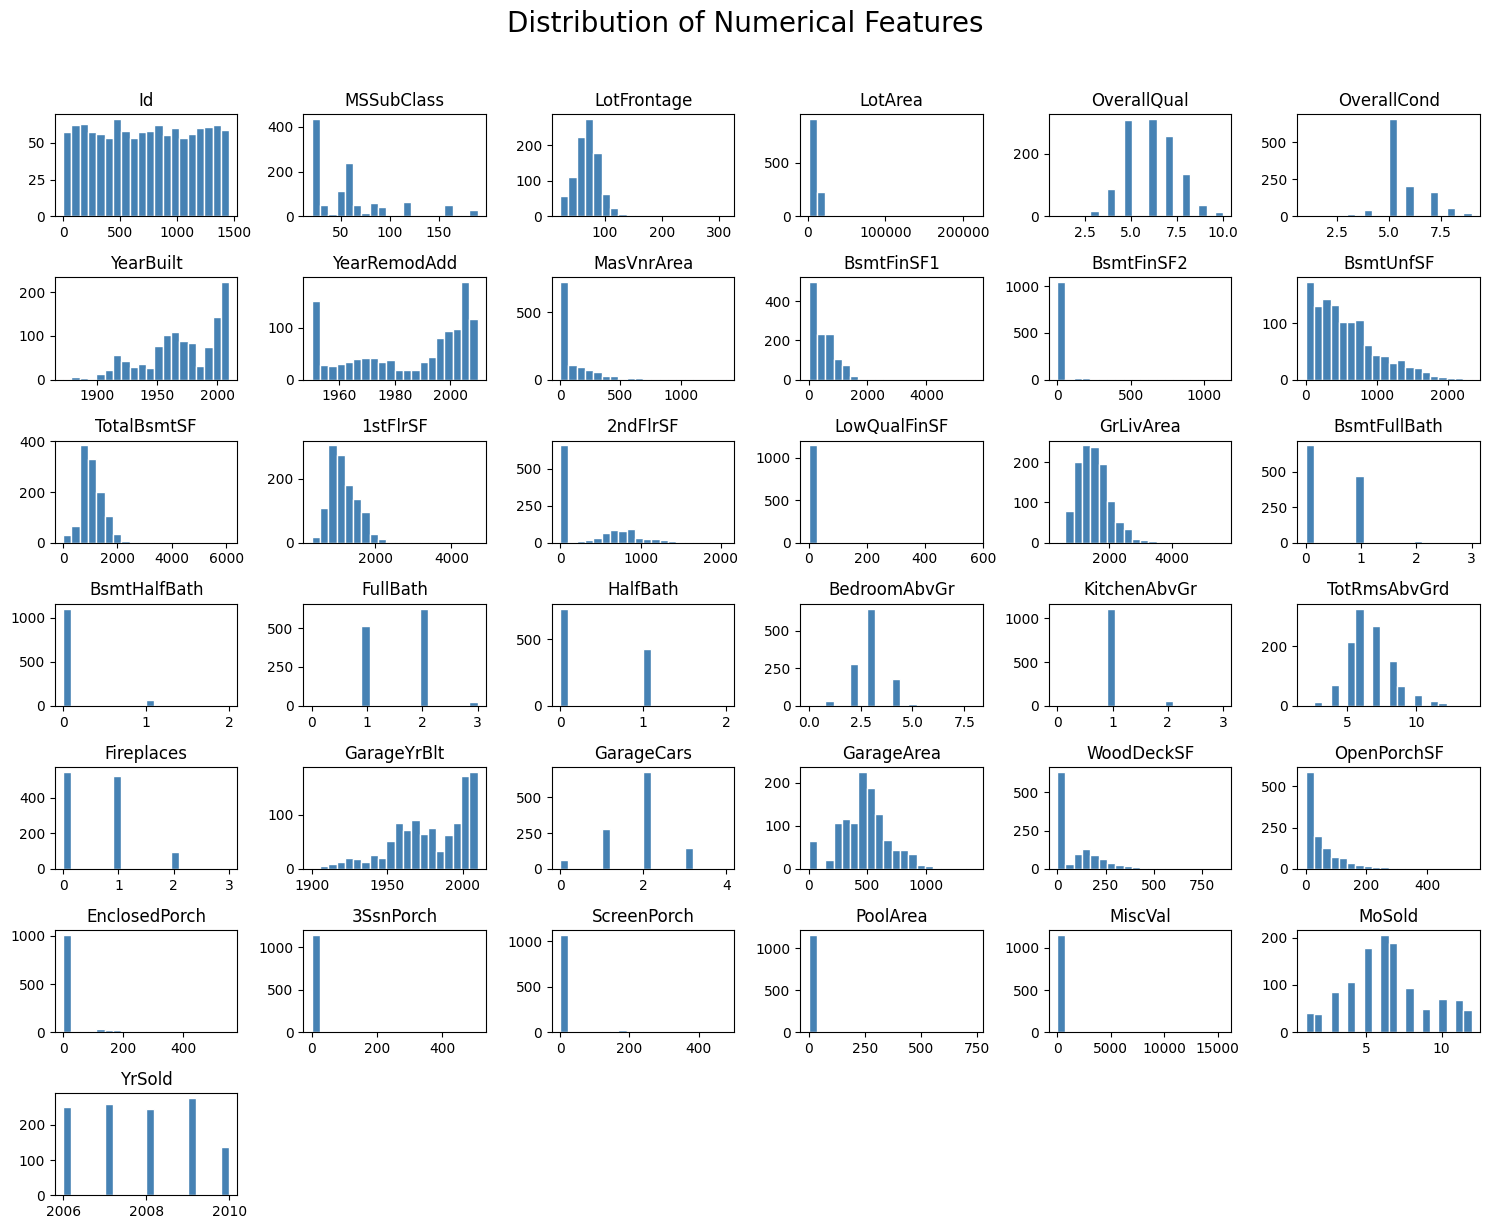

In [10]:
X_train[num_cols].hist(bins=20, figsize=(15, 12), color='steelblue', edgecolor='white', grid=False)

import matplotlib.pyplot as plt

plt.suptitle('Distribution of Numerical Features', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

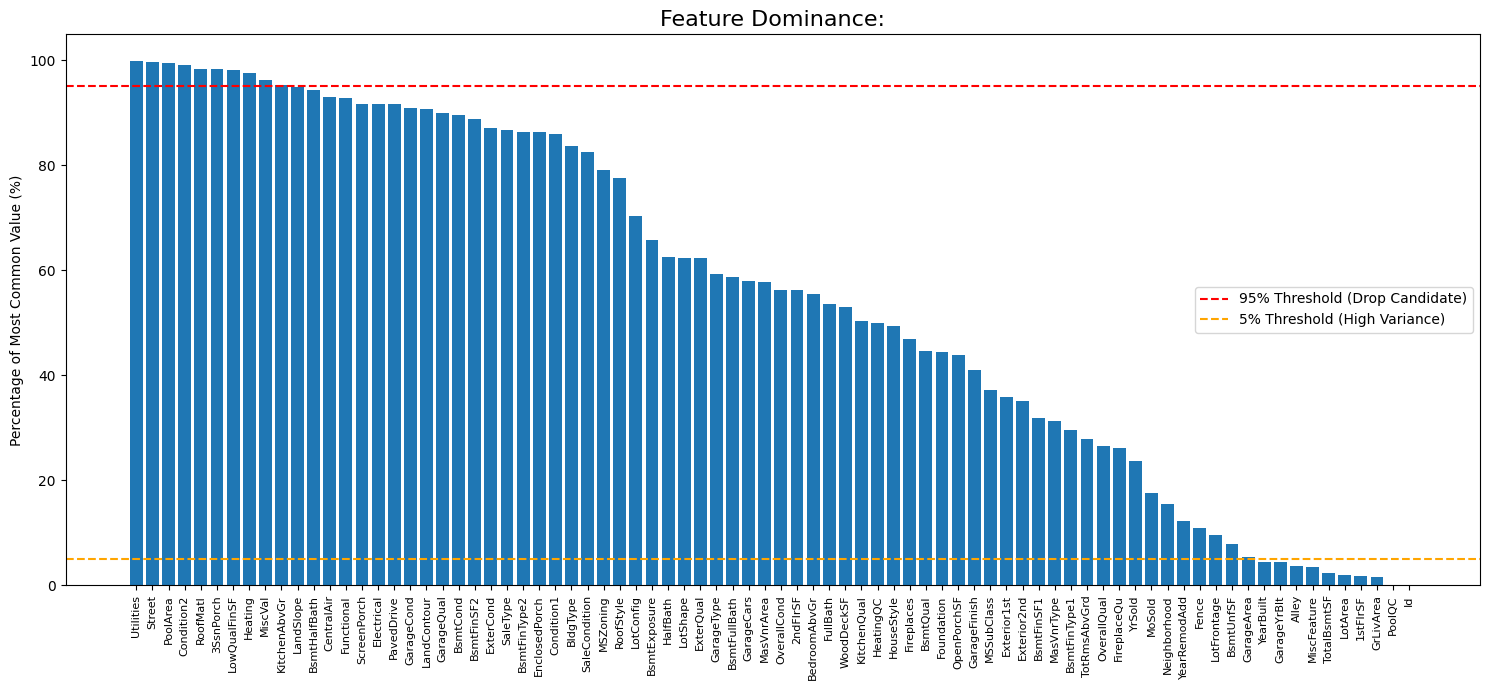

Columns to consider dropping (>95% same value): ['Utilities', 'Street', 'PoolArea', 'Condition2', 'RoofMatl', '3SsnPorch', 'LowQualFinSF', 'Heating', 'MiscVal', 'KitchenAbvGr']


In [11]:
dominance = X_train.apply(lambda x: x.value_counts().iloc[0] / len(x) * 100)
dom_df = dominance.sort_values(ascending=False).reset_index()
dom_df.columns = ['column', 'max_prev_pct']

plt.figure(figsize=(15, 7))
plt.bar(dom_df['column'], dom_df['max_prev_pct'])

plt.axhline(y=95, color='red', linestyle='--', label='95% Threshold (Drop Candidate)')
plt.axhline(y=5, color='orange', linestyle='--', label='5% Threshold (High Variance)')

plt.title('Feature Dominance:', fontsize=16)
plt.ylabel('Percentage of Most Common Value (%)')
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

junk_candidates = dom_df[dom_df['max_prev_pct'] > 95]['column'].tolist()
print(f"Columns to consider dropping (>95% same value): {junk_candidates}")

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      217
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
Length: 80, dtype: int64
total - 6227

Missing Data Analysis

              Missing Count  Percentage (%)
PoolQC                 1162       99.486301
MiscFeature            1122       96.061644
Alley                  1094       93.664384
Fence                   935       80.051370
MasVnrType              683       58.476027
FireplaceQu             547       46.832192
LotFrontage             217       18.578767
GarageType               64        5.479452
GarageYrBlt              64        5.479452
GarageFinish             64        5.479452
GarageQual               64        5.479452
GarageCond               64        5.479452
BsmtCond                 28        2.397260
BsmtFinType1             28        2.397260
BsmtExposure             28        2.397260
Bsm

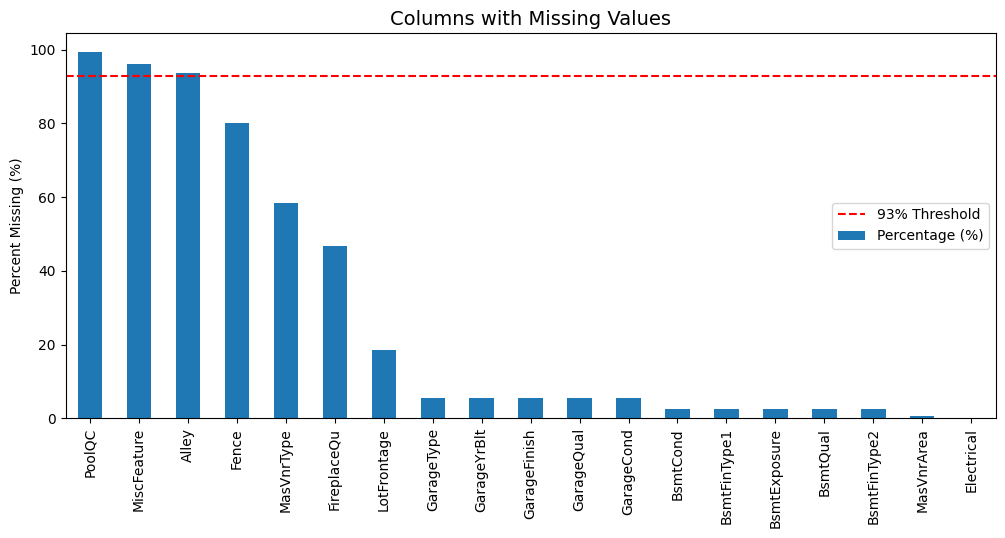

In [12]:
null_counts = X_train.isnull().sum()
null_counts_total = null_counts.sum()
print(null_counts)
print(f"total - {null_counts_total}")
print()


print("Missing Data Analysis")
null_percent = (null_counts / len(X_train)) * 100

null_report = pd.DataFrame({
    'Missing Count': null_counts,
    'Percentage (%)': null_percent
})

null_report = null_report[null_report['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

print()
print(null_report)



plt.figure(figsize=(12, 5))
null_report['Percentage (%)'].head(20).plot(kind='bar')
plt.axhline(y=93, color='red', linestyle='--', label='93% Threshold')
plt.title("Columns with Missing Values", fontsize=14)
plt.ylabel("Percent Missing (%)")
plt.legend()
plt.show()

**cleaning**

**column dropping**

In [13]:
from sklearn.impute import SimpleImputer

X_train_cleaned = X_train.copy()
X_val_cleaned = X_val.copy()
    
if 'Id' in X_train_cleaned.columns:
    X_train_cleaned = X_train_cleaned.drop(columns=['Id'])

if 'Id' in X_val_cleaned.columns:
    X_val_cleaned = X_val_cleaned.drop(columns=['Id'])
    
    
high_null_cols = ['PoolQC', 'MiscFeature', 'Alley']
X_train_cleaned = X_train_cleaned.drop(columns=[c for c in high_null_cols if c in X_train_cleaned.columns])
X_val_cleaned = X_val_cleaned.drop(columns=[c for c in high_null_cols if c in X_val_cleaned.columns])

junk_cols = ['Utilities', 'Street', 'PoolArea', 'Condition2', 'RoofMatl', '3SsnPorch', 'LowQualFinSF', 'Heating', 'MiscVal', 'KitchenAbvGr']
X_train_cleaned = X_train_cleaned.drop(columns=[c for c in junk_cols if c in X_train_cleaned.columns])
X_val_cleaned = X_val_cleaned.drop(columns=[c for c in junk_cols if c in X_val_cleaned.columns])

In [14]:
print("features before and after column dropping: ")
print(f"before - {X_train.shape[1]}")
print(f"after - {X_train_cleaned.shape[1]}")

features before and after column dropping: 
before - 80
after - 66


**nans**

In [15]:
num_cols = X_train_cleaned.select_dtypes(exclude=['object']).columns
cat_cols = X_train_cleaned.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_cleaned[num_cols] = num_imputer.fit_transform(X_train_cleaned[num_cols])
X_train_cleaned[cat_cols] = cat_imputer.fit_transform(X_train_cleaned[cat_cols])

X_val_cleaned[num_cols] = num_imputer.transform(X_val_cleaned[num_cols])
X_val_cleaned[cat_cols] = cat_imputer.transform(X_val_cleaned[cat_cols])

In [16]:
print("features before and after organising nans: ")
print(f"before - {X_train.isnull().sum().sum()}")
print(f"after - {X_train_cleaned.isnull().sum().sum()}")

features before and after organising nans: 
before - 6227
after - 0


In [17]:
print(f"features after cleaning and before feature engineering - {X_train_cleaned.shape[1]}")

features after cleaning and before feature engineering - 66


**feature engineering**

In [18]:
X_train_fe = X_train_cleaned.copy()
X_val_fe = X_val_cleaned.copy()

In [19]:
def add_features(df):
    df = df.copy()

    # when column is already dropped --
    def safe_col(col):
        return df[col] if col in df.columns else 0

    # Total house area
    df["TotalSF"] = (
        safe_col("TotalBsmtSF") +
        safe_col("1stFlrSF") +
        safe_col("2ndFlrSF")
    )

    # Total bathrooms
    df["TotalBathrooms"] = (
        safe_col("FullBath") +
        0.5 * safe_col("HalfBath") +
        safe_col("BsmtFullBath") +
        0.5 * safe_col("BsmtHalfBath")
    )

    # Total porch area
    df["TotalPorchSF"] = (
        safe_col("OpenPorchSF") +
        safe_col("EnclosedPorch") +
        safe_col("ScreenPorch")
    )

    # Age features
    df["HouseAge"] = safe_col("YrSold") - safe_col("YearBuilt")
    df["RemodAge"] = safe_col("YrSold") - safe_col("YearRemodAdd")

    # Garage age
    df["GarageAge"] = safe_col("YrSold") - safe_col("GarageYrBlt")

    # Quality interaction
    df["Qual_x_GrLivArea"] = (
        safe_col("OverallQual") * safe_col("GrLivArea")
    )

    # Basement total
    df["TotalBsmt"] = (
        safe_col("BsmtFinSF1") +
        safe_col("BsmtFinSF2") +
        safe_col("BsmtUnfSF")
    )

    # Room density
    df["RoomsPerArea"] = (
        safe_col("TotRmsAbvGrd") /
        (safe_col("GrLivArea") + 1)
    )

    return df


X_train_fe = add_features(X_train_fe)
X_val_fe = add_features(X_val_fe)

In [20]:
print(f"after adding features: {X_train_fe.shape[1]}")

after adding features: 75


In [21]:
cols_to_drop = [
    # Basement components (now in TotalBsmt and TotalSF)
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", 
    
    # Floor components (now in TotalSF)
    "1stFlrSF", "2ndFlrSF", 
    
    # Bathroom components (now in TotalBathrooms)
    "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath",
    
    # Age components (now in HouseAge and RemodAge)
    "YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold",
    
    # Porch components (now in TotalPorchSF)
    "OpenPorchSF", "EnclosedPorch", "ScreenPorch",
    
    # Room components (now represented by RoomsPerArea)
    "TotRmsAbvGrd"
]

X_train_fe = X_train_fe.drop(columns=cols_to_drop)
X_val_fe = X_val_fe.drop(columns=cols_to_drop)

In [22]:
print(f"after dropping: {X_train_fe.shape[1]}")

after dropping: 57


In [23]:
from scipy.stats import skew

numeric_cols = X_train_fe.select_dtypes(include=['int64', 'float64']).columns

skewness = X_train_fe[numeric_cols].apply(lambda x: skew(x)).sort_values(ascending=False)
skewed_features = skewness[skewness > 0.75].index

print(f"skewed features: {skewed_features}")

skewed features: Index(['LotArea', 'LotFrontage', 'MasVnrArea', 'TotalPorchSF',
       'Qual_x_GrLivArea', 'TotalSF', 'TotalBsmt', 'WoodDeckSF', 'MSSubClass',
       'GrLivArea'],
      dtype='object')


In [24]:
for col in skewed_features:
    X_train_fe[col] = np.log1p(X_train_fe[col])
    X_val_fe[col] = np.log1p(X_val_fe[col])

In [25]:
from sklearn.preprocessing import OneHotEncoder

num_cols = X_train_fe.select_dtypes(exclude='object').columns.tolist()
cat_cols = X_train_fe.select_dtypes(include='object').columns.tolist()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_cat_encoded = ohe.fit_transform(X_train_fe[cat_cols])
val_cat_encoded = ohe.transform(X_val_fe[cat_cols])

encoded_cols = ohe.get_feature_names_out(cat_cols)


train_cat_df = pd.DataFrame(
    train_cat_encoded,
    columns=encoded_cols,
    index=X_train_fe.index
)

val_cat_df = pd.DataFrame(
    val_cat_encoded,
    columns=encoded_cols,
    index=X_val_fe.index
)


X_train_fe_final = pd.concat([X_train_fe[num_cols], train_cat_df], axis=1)
X_val_fe_final = pd.concat([X_val_fe[num_cols], val_cat_df], axis=1)


print(f"final train: {X_train_fe_final.shape[1]}")
print(f"final val: {X_val_fe_final.shape[1]}")

print(f"missing values (train): {X_train_fe_final.isnull().sum().sum()}")
print(f"missing values (val): {X_val_fe_final.isnull().sum().sum()}")

final train: 237
final val: 237
missing values (train): 0
missing values (val): 0


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_fe_final)
X_val_scaled = scaler.transform(X_val_fe_final)

In [27]:
print("after sclaing")
print(f"train: {X_train_scaled.shape[1]}")
print(f"val: {X_val_scaled.shape[1]}")

after sclaing
train: 237
val: 237


In [28]:
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train_fe_final.columns)
X_val_df = pd.DataFrame(X_val_scaled, columns=X_train_fe_final.columns)

**feature selection**

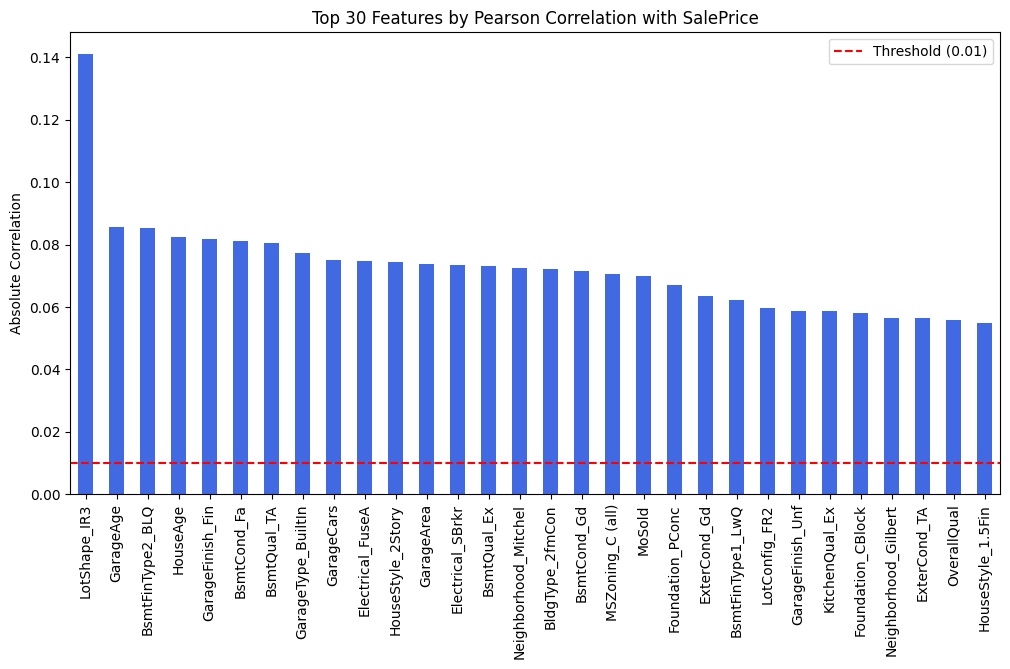

Dropping 60 features with correlation < 0.01
Features remaining after Stage 1: 177


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Pearson correlation with target using your specific training dataframe
target_corr = X_train_df.corrwith(y_train).abs().sort_values(ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
target_corr.head(30).plot(kind='bar', color='royalblue')
plt.axhline(y=0.01, color='red', linestyle='--', label='Threshold (0.01)')
plt.title("Top 30 Features by Pearson Correlation with SalePrice")
plt.ylabel("Absolute Correlation")
plt.legend()
plt.show()

# Filter (Stage 1)
low_corr_cols = target_corr[target_corr < 0.01].index.tolist()
print(f"Dropping {len(low_corr_cols)} features with correlation < 0.01")

X_train_stage1 = X_train_df.drop(columns=low_corr_cols)
X_val_stage1 = X_val_df.drop(columns=low_corr_cols)

print(f"Features remaining after Stage 1: {X_train_stage1.shape[1]}")

In [30]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

n_features_to_select = 80

lr_selector = LinearRegression()
rfe = RFE(estimator=lr_selector, n_features_to_select=n_features_to_select, step=1)

print(f"Running RFE to select the top {n_features_to_select} features...")
rfe.fit(X_train_stage1, y_train)

selected_cols = X_train_stage1.columns[rfe.support_]

X_train_selected = X_train_stage1[selected_cols]
X_val_selected = X_val_stage1[selected_cols]

print(f"Feature Selection Complete!")
print(f"Final Train shape: {X_train_selected.shape}")
print(f"Final Val shape: {X_val_selected.shape}")

Running RFE to select the top 80 features...
Feature Selection Complete!
Final Train shape: (1168, 80)
Final Val shape: (292, 80)


In [31]:
import joblib

# Export preprocessing state
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(ohe, 'ohe.pkl')
joblib.dump(num_imputer, 'num_imputer.pkl')
joblib.dump(cat_imputer, 'cat_imputer.pkl')
joblib.dump(skewed_features, 'skewed_features.pkl')
joblib.dump(X_train_selected.columns.tolist(), 'final_features.pkl')

# List of files to upload to MLflow
artifacts = ['scaler.pkl', 'ohe.pkl', 'num_imputer.pkl', 'cat_imputer.pkl', 'skewed_features.pkl', 'final_features.pkl']

**training**

In [32]:
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

artifact_paths = {
    "scaler": "scaler.pkl",
    "ohe": "ohe.pkl",
    "cat_imputer": "cat_imputer.pkl",
    "num_imputer": "num_imputer.pkl",
    "skewed_features": "skewed_features.pkl",
    "final_features": "final_features.pkl"
}

def evaluate(model, X_tr, y_tr, X_v, y_v):
    tr_preds = model.predict(X_tr)
    v_preds  = model.predict(X_v)
    train_rmse = np.sqrt(mean_squared_error(y_tr, tr_preds))
    val_rmse   = np.sqrt(mean_squared_error(y_v,  v_preds))
    return {
        "train_rmse":  train_rmse,
        "val_rmse":    val_rmse,
        "overfit_gap": val_rmse - train_rmse
    }

def log_and_print(model,metrics, run_name):
    for k, v in metrics.items():
        mlflow.log_metric(k, v)

    mlflow.sklearn.log_model(model, "model")
    for name, path in artifact_paths.items():
        mlflow.log_artifact(path, artifact_path="model")
        
    print(f"[{run_name}] train={metrics['train_rmse']:.4f} | val={metrics['val_rmse']:.4f} | gap={metrics['overfit_gap']:.4f}")

In [33]:
mlflow.set_experiment("House_Prices_Linear_Models")

# Baseline Linear Regression
with mlflow.start_run(run_name="LR_baseline"):
    mlflow.set_tag("group", "linear_regression")
    mlflow.log_param("model", "LinearRegression")
    model = LinearRegression()
    model.fit(X_train_selected, y_train)
    metrics = evaluate(model, X_train_selected, y_train, X_val_selected, y_val)
    
    log_and_print(model, metrics, "LR_baseline")
    
# Ridge
for alpha in [0.1, 1.0, 10.0, 50.0, 100.0]:
    with mlflow.start_run(run_name=f"Ridge_alpha_{alpha}"):
        mlflow.log_param("model", "Ridge")
        mlflow.log_param("alpha", alpha)
        model = Ridge(alpha=alpha)
        model.fit(X_train_selected, y_train)
        metrics = evaluate(model, X_train_selected, y_train, X_val_selected, y_val)
        
        log_and_print(model, metrics, f"Ridge_alpha_{alpha}")


# Lasso 
for alpha in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    with mlflow.start_run(run_name=f"Lasso_alpha_{alpha}"):
        mlflow.log_param("model", "Lasso")
        mlflow.log_param("alpha", alpha)
        model = Lasso(alpha=alpha, max_iter=5000)
        model.fit(X_train_selected, y_train)
        metrics = evaluate(model, X_train_selected, y_train, X_val_selected, y_val)
        
        log_and_print(model, metrics, f"Lasso_alpha_{alpha}")
        


2026/04/15 19:14:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:14:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LR_baseline] train=0.1127 | val=0.1322 | gap=0.0195
🏃 View run LR_baseline at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18/runs/8d86870cff73406d802d2e3447422ebb
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18


2026/04/15 19:14:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:15:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Ridge_alpha_0.1] train=0.1127 | val=0.1321 | gap=0.0194
🏃 View run Ridge_alpha_0.1 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18/runs/ca614e4cd2914f4e8771df142915b1df
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18


2026/04/15 19:15:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:15:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

[Lasso_alpha_0.01] train=0.1280 | val=0.1356 | gap=0.0076
🏃 View run Lasso_alpha_0.01 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18/runs/d8b0e76d331d43448a86164e12cc7477
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18


2026/04/15 19:18:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:19:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Lasso_alpha_0.1] train=0.2070 | val=0.2248 | gap=0.0178
🏃 View run Lasso_alpha_0.1 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18/runs/07008f11ab464d0cb6fd02b00e6a6610
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18


2026/04/15 19:19:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:19:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Lasso_alpha_1.0] train=0.3904 | val=0.4332 | gap=0.0428
🏃 View run Lasso_alpha_1.0 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18/runs/74810bc2a22641e7a83c799b6cb0fbe0
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/18


In [34]:
mlflow.set_experiment("House_Prices_Decision_Trees")

params_to_sweep = {
    "depth": [3, 5, 8, 12, 20, None],
    "min_split": [2, 10, 20, 50, 100],
    "max_feat": ["sqrt", "log2", 0.5, 0.8, None]
}

# Depth Sweep
for depth in params_to_sweep["depth"]:
    with mlflow.start_run(run_name=f"DT_depth_{depth}"):
        mlflow.log_param("max_depth", str(depth))
        model = DecisionTreeRegressor(max_depth=depth, random_state=42)
        model.fit(X_train_selected, y_train)
        metrics = evaluate(model, X_train_selected, y_train, X_val_selected, y_val)
        
        log_and_print(model, metrics, f"DT_depth_{depth}")
        

# min_samples_split Sweep
for min_split in params_to_sweep["min_split"]:
    with mlflow.start_run(run_name=f"DT_minsplit_{min_split}"):
        mlflow.log_param("min_samples_split", min_split)
        model = DecisionTreeRegressor(max_depth=8, min_samples_split=min_split, random_state=42)
        model.fit(X_train_selected, y_train)
        metrics = evaluate(model, X_train_selected, y_train, X_val_selected, y_val)
        
        log_and_print(model, metrics, f"DT_minsplit_{min_split}")


# max_feat Sweep
for max_feat in ["sqrt", "log2", 0.5, 0.8, None]:
    with mlflow.start_run(run_name=f"DT_maxfeatures_{max_feat}"):
        mlflow.set_tag("group", "decision_tree")
        mlflow.set_tag("reason", f"feature subsampling at split, max_features={max_feat}")
        mlflow.log_param("model", "DecisionTreeRegressor")
        mlflow.log_param("max_depth", 8)
        mlflow.log_param("max_features", str(max_feat))
        mlflow.log_param("num_features", X_train_selected.shape[1])

        model = DecisionTreeRegressor(max_depth=8, max_features=max_feat, random_state=42)
        model.fit(X_train_selected, y_train)

        metrics = evaluate(model, X_train_selected, y_train, X_val_selected, y_val)
        
        log_and_print(model, metrics, f"DT_maxfeatures_{max_feat}")
        

2026/04/15 19:19:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:20:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[DT_depth_3] train=0.1974 | val=0.2260 | gap=0.0286
🏃 View run DT_depth_3 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19/runs/5f6acacb961c4380b21faf48dca74d69
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19


2026/04/15 19:20:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:20:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[DT_depth_5] train=0.1472 | val=0.1890 | gap=0.0418
🏃 View run DT_depth_5 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19/runs/cd156b908d8543cb89cd4dd1f40d427b
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19


2026/04/15 19:20:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:21:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

[DT_maxfeatures_0.5] train=0.0948 | val=0.1867 | gap=0.0919
🏃 View run DT_maxfeatures_0.5 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19/runs/8fdd4139b2a14df6b9b131040e0ae054
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19


2026/04/15 19:27:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:27:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[DT_maxfeatures_0.8] train=0.0849 | val=0.1796 | gap=0.0947
🏃 View run DT_maxfeatures_0.8 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19/runs/2863d749b9bd4eb880658610efc548c4
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19


2026/04/15 19:27:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:27:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[DT_maxfeatures_None] train=0.0869 | val=0.1839 | gap=0.0970
🏃 View run DT_maxfeatures_None at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19/runs/ab5c92ef74ab48539370a64d96b45dbe
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/19


In [35]:
mlflow.set_experiment("House_Prices_Random_Forests")

# n_estimators Sweep
for n_est in [50, 100, 200, 400]:
    with mlflow.start_run(run_name=f"RF_nestimators_{n_est}"):
        mlflow.log_param("n_estimators", n_est)
        model = RandomForestRegressor(n_estimators=n_est, random_state=42, n_jobs=-1)
        model.fit(X_train_selected, y_train)
        metrics = evaluate(model, X_train_selected, y_train, X_val_selected, y_val)
        
        log_and_print(model, metrics, f"RF_nestimators_{n_est}")
        
# max_depth Sweep
for depth in [10, 15, 20, 30, None]:
    with mlflow.start_run(run_name=f"RF_depth_{depth}"):
        mlflow.log_param("max_depth", str(depth))
        model = RandomForestRegressor(n_estimators=200, max_depth=depth, random_state=42, n_jobs=-1)
        model.fit(X_train_selected, y_train)
        metrics = evaluate(model, X_train_selected, y_train, X_val_selected, y_val)
        
        log_and_print(model, metrics, f"RF_depth_{depth}")
        
# min_samples_leaf Sweep
for min_leaf in [1, 2, 4, 8, 16]:
    with mlflow.start_run(run_name=f"RF_minleaf_{min_leaf}"):
        mlflow.log_param("min_samples_leaf", min_leaf)
        model = RandomForestRegressor(n_estimators=200, min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
        model.fit(X_train_selected, y_train)
        metrics = evaluate(model, X_train_selected, y_train, X_val_selected, y_val)
        
        log_and_print(model, metrics, f"RF_minleaf_{min_leaf}")

2026/04/15 19:28:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:28:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_nestimators_50] train=0.0551 | val=0.1483 | gap=0.0933
🏃 View run RF_nestimators_50 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20/runs/70cbe0a1a32845248563ca8686c4183c
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20


2026/04/15 19:28:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:28:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_nestimators_100] train=0.0532 | val=0.1484 | gap=0.0953
🏃 View run RF_nestimators_100 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20/runs/2f5743cf44e34b5ab3a068038be995cb
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20


2026/04/15 19:29:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:29:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

[RF_minleaf_4] train=0.0893 | val=0.1536 | gap=0.0643
🏃 View run RF_minleaf_4 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20/runs/8b8450ce8c6743c5aafa3c740472beac
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20


2026/04/15 19:33:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:34:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_minleaf_8] train=0.1140 | val=0.1582 | gap=0.0442
🏃 View run RF_minleaf_8 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20/runs/e6321e302d574de78f75df24e36828b7
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20


2026/04/15 19:34:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:34:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_minleaf_16] train=0.1349 | val=0.1682 | gap=0.0333
🏃 View run RF_minleaf_16 at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20/runs/76c1e8074a4a4381a409fabd8b447a1b
🧪 View experiment at: https://dagshub.com/akeke23/ml_ass1.mlflow/#/experiments/20
